In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA environment loaded successfully.")

EDA environment loaded successfully.


In [4]:
coverage = pd.read_csv("../data/cleaned/coverage_cleaned.csv")
incidence = pd.read_csv("../data/cleaned/incidence_cleaned.csv")
reported_cases = pd.read_csv("../data/cleaned/reported_cases_cleaned.csv")
vaccine_introduction = pd.read_csv("../data/cleaned/vaccine_introduction_cleaned.csv")
vaccine_schedule = pd.read_csv("../data/cleaned/vaccine_schedule_cleaned.csv")

print("Coverage:", coverage.shape)
print("Incidence:", incidence.shape)
print("Reported Cases:", reported_cases.shape)
print("Vaccine Introduction:", vaccine_introduction.shape)
print("Vaccine Schedule:", vaccine_schedule.shape)

Coverage: (399858, 11)
Incidence: (84945, 8)
Reported Cases: (84869, 7)
Vaccine Introduction: (138320, 6)
Vaccine Schedule: (8052, 12)


In [5]:
coverage.head()

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [6]:
coverage["COVERAGE"].describe()

count    230477.000000
mean         78.032914
std          74.891697
min           0.000000
25%          69.320000
50%          88.790000
75%          96.000000
max       32000.000000
Name: COVERAGE, dtype: float64

In [7]:
coverage[
    coverage["COVERAGE"] > 100
][
    ["CODE", "NAME", "YEAR", "ANTIGEN", "ANTIGEN_DESCRIPTION", "COVERAGE"]
].sort_values("COVERAGE", ascending=False).head(20)

,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE
207060,MAR,Morocco,2018,FLU_HAJ,Influenza travellers (incl. Hajj pilgrimage),32000.00
117327,FSM,Micronesia (Federated States of),2020,VAD1,"Vitamin A, 1st dose",6604.00
4683,AIA,Anguilla,2020,HPV_FEM,"HPV Female, final dose",6100.00
217675,MHL,Marshall Islands,2023,VAD1,"Vitamin A, 1st dose",4868.00
138238,GTM,Guatemala,2018,FLU_CHILD1,Influenza child age group 1,2630.00
3296,AGO,Angola,2014,IPV1,"Inactivated polio-containing vaccine, 1st dose",1035.00
235477,MSR,Montserrat,2000,POL3,"Polio, 3rd dose",856.00
324055,SYC,Seychelles,2022,HPV_FEM,"HPV Female, final dose",687.00
322120,SWZ,Eswatini,2021,YFV,Yellow fever vaccine,609.00
144226,HND,Honduras,2020,FLU_CHRONIC_PED,Influenza chronic pediatric,457.24


In [8]:
coverage_eda = coverage[
    coverage["COVERAGE"].between(0, 100)
].copy()

print("Original coverage rows:", len(coverage))
print("Rows used for EDA:", len(coverage_eda))
print("Rows excluded:", len(coverage) - len(coverage_eda))

Original coverage rows: 399858
Rows used for EDA: 225380
Rows excluded: 174478


In [9]:
coverage_by_year = (
    coverage_eda
    .groupby("YEAR", as_index=False)["COVERAGE"]
    .mean()
)

coverage_by_year["COVERAGE"] = coverage_by_year["COVERAGE"].round(2)

coverage_by_year.head()

,YEAR,COVERAGE
0,1980,44.25
1,1981,46.12
2,1982,48.78
3,1983,52.86
4,1984,53.97


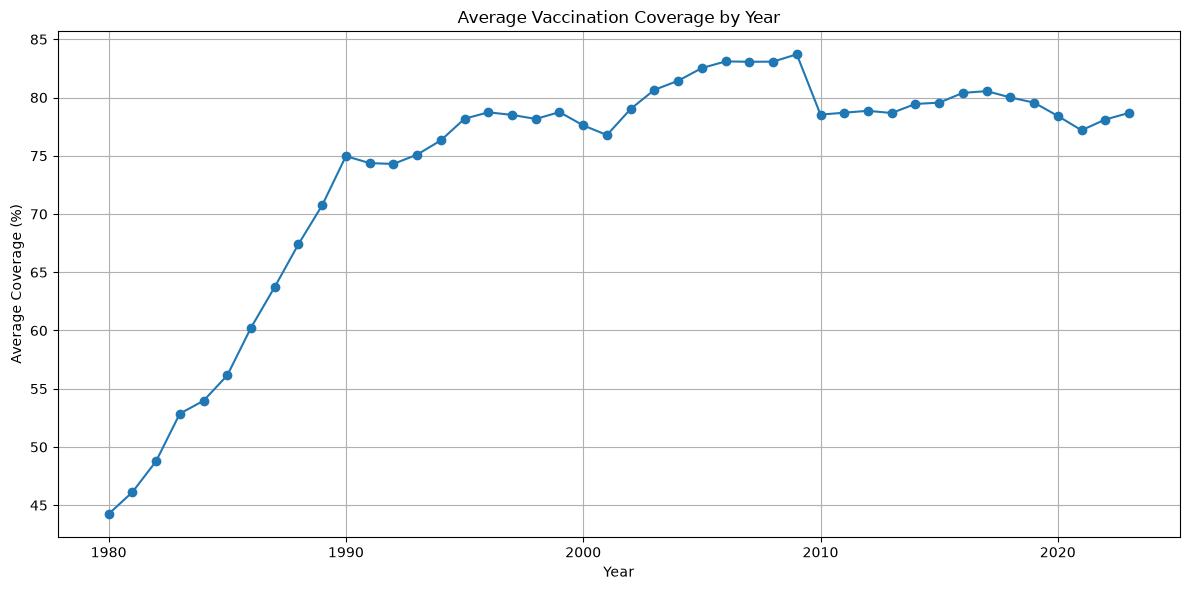

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    coverage_by_year["YEAR"],
    coverage_by_year["COVERAGE"],
    marker="o"
)

plt.title("Average Vaccination Coverage by Year")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.grid(True)
plt.tight_layout()

plt.show()

In [11]:
coverage_by_year.tail(10)

,YEAR,COVERAGE
34,2014,79.45
35,2015,79.56
36,2016,80.40
37,2017,80.55
38,2018,80.01
39,2019,79.56
40,2020,78.42
41,2021,77.19
42,2022,78.11
43,2023,78.68


In [12]:
incidence.head()

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,"per 1,000,000 total population",0.0


In [13]:
incidence["INCIDENCE_RATE"].describe()

count    61584.000000
mean       109.448781
std        992.276983
min          0.000000
25%          0.000000
50%          0.000000
75%          4.600000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64

In [14]:
incidence["INCIDENCE_RATE"].describe()

count    61584.000000
mean       109.448781
std        992.276983
min          0.000000
25%          0.000000
50%          0.000000
75%          4.600000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64

In [15]:
incidence[
    incidence["INCIDENCE_RATE"].notna()
][
    [
        "CODE",
        "NAME",
        "YEAR",
        "DISEASE",
        "DISEASE_DESCRIPTION",
        "DENOMINATOR",
        "INCIDENCE_RATE"
    ]
].sort_values(
    "INCIDENCE_RATE",
    ascending=False
).head(20)

,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
77891,TUV,Tuvalu,1980,MEASLES,Measles,"per 1,000,000 total population",69101.3
41112,KIR,Kiribati,1992,MEASLES,Measles,"per 1,000,000 total population",56116.5
56510,NIU,Niue,1991,MEASLES,Measles,"per 1,000,000 total population",49347.5
12213,BTN,Bhutan,1999,MUMPS,Mumps,"per 1,000,000 total population",43863.6
67470,SLB,Solomon Islands,1989,MEASLES,Measles,"per 1,000,000 total population",42887.6
1906,ALB,Albania,1989,MEASLES,Measles,"per 1,000,000 total population",41723.4
16738,COK,Cook Islands,1989,MEASLES,Measles,"per 1,000,000 total population",40810.3
58997,OMN,Oman,1981,MEASLES,Measles,"per 1,000,000 total population",38473.7
4443,ATG,Antigua and Barbuda,1980,MEASLES,Measles,"per 1,000,000 total population",35512.2
77842,TUV,Tuvalu,1987,MEASLES,Measles,"per 1,000,000 total population",33926.7


In [16]:
incidence_by_year = (
    incidence
    .dropna(subset=["INCIDENCE_RATE"])
    .groupby("YEAR", as_index=False)["INCIDENCE_RATE"]
    .mean()
)

incidence_by_year["INCIDENCE_RATE"] = (
    incidence_by_year["INCIDENCE_RATE"].round(2)
)

incidence_by_year.head()

,YEAR,INCIDENCE_RATE
0,1980,836.04
1,1981,633.87
2,1982,588.09
3,1983,487.96
4,1984,435.62


In [17]:
incidence_by_year.head(10)

,YEAR,INCIDENCE_RATE
0,1980,836.04
1,1981,633.87
2,1982,588.09
3,1983,487.96
4,1984,435.62
5,1985,479.37
6,1986,272.42
7,1987,277.41
8,1988,204.04
9,1989,342.14


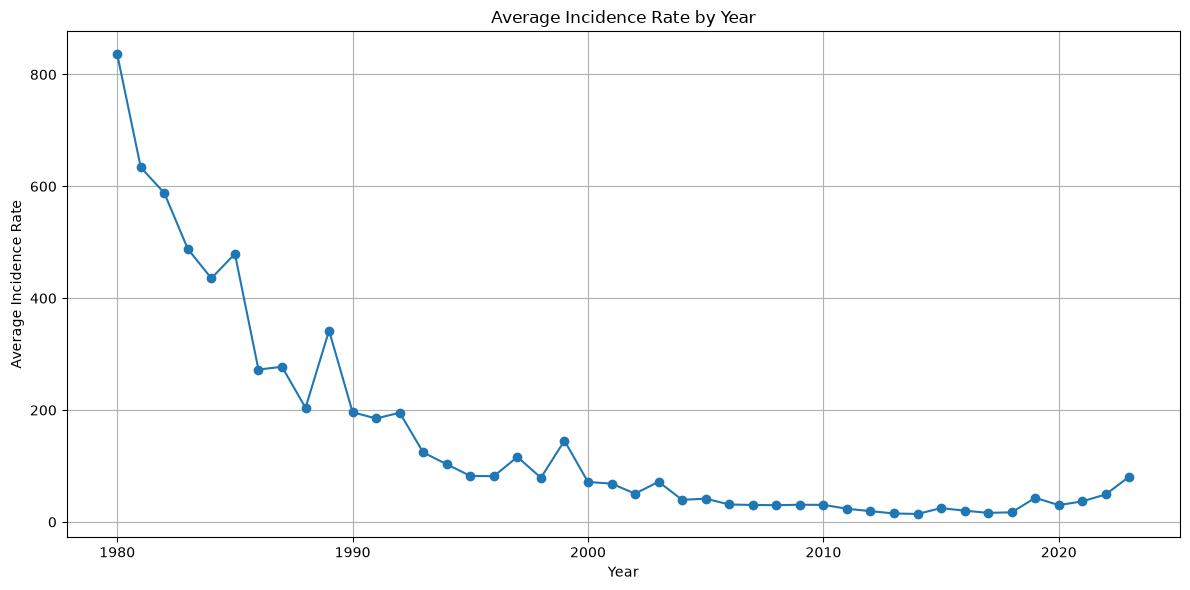

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    incidence_by_year["YEAR"],
    incidence_by_year["INCIDENCE_RATE"],
    marker="o"
)

plt.title("Average Incidence Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Incidence Rate")
plt.grid(True)
plt.tight_layout()

plt.show()

In [19]:
reported_cases.head()
reported_cases["CASES"].describe()

count    6.547000e+04
mean     4.472409e+03
std      6.114455e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      6.300000e+01
max      4.583555e+06
Name: CASES, dtype: float64

In [20]:
reported_cases_by_year = (
    reported_cases
    .dropna(subset=["CASES"])
    .groupby("YEAR", as_index=False)["CASES"]
    .sum()
)

reported_cases_by_year["CASES"] = (
    reported_cases_by_year["CASES"].round(0)
)

reported_cases_by_year.head(10)

,YEAR,CASES
0,1980,18295920.0
1,1981,18400813.0
2,1982,17054356.0
3,1983,15465282.0
4,1984,12728064.0
5,1985,12093687.0
6,1986,9252891.0
7,1987,7612200.0
8,1988,7096478.0
9,1989,7758531.0


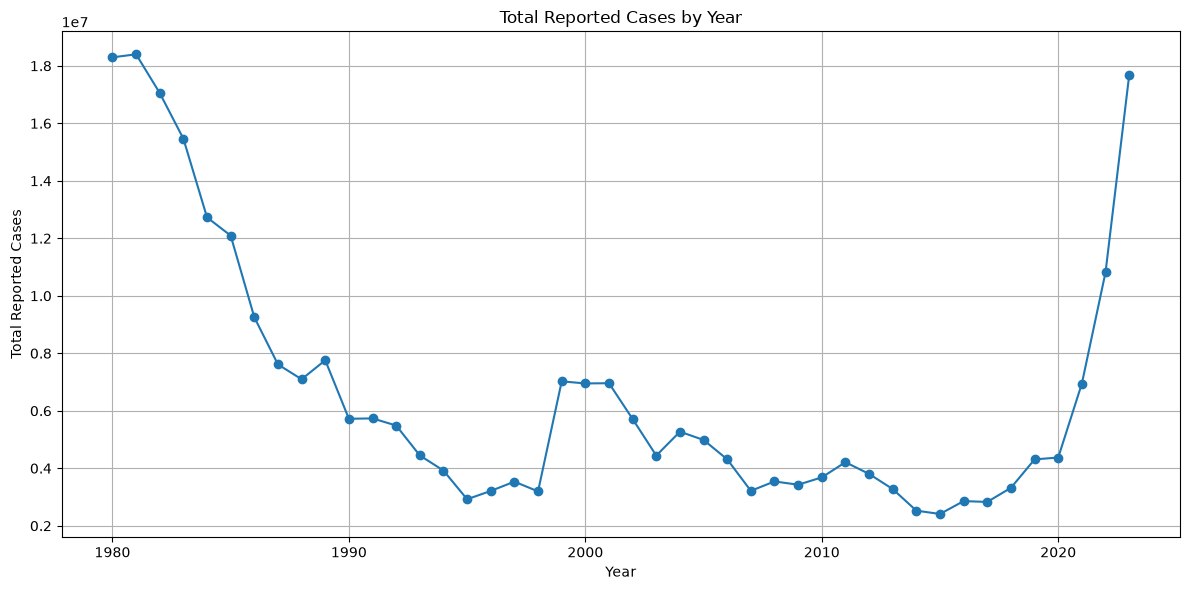

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    reported_cases_by_year["YEAR"],
    reported_cases_by_year["CASES"],
    marker="o"
)

plt.title("Total Reported Cases by Year")
plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.grid(True)
plt.tight_layout()

plt.show()

In [22]:
reported_cases_by_disease = (
    reported_cases
    .dropna(subset=["CASES"])
    .groupby(
        ["DISEASE", "DISEASE_DESCRIPTION"],
        as_index=False
    )["CASES"]
    .sum()
    .sort_values("CASES", ascending=False)
)

reported_cases_by_disease["CASES"] = (
    reported_cases_by_disease["CASES"].round(0)
)

reported_cases_by_disease

,DISEASE,DISEASE_DESCRIPTION,CASES
4,MEASLES,Measles,144065673.0
7,PERTUSSIS,Pertussis,53089864.0
5,MUMPS,Mumps,36326936.0
11,TYPHOID,Typhoid,31153098.0
9,RUBELLA,Rubella,16655663.0
10,TTETANUS,Total tetanus,4888011.0
1,DIPHTHERIA,Diphtheria,2908251.0
8,POLIO,Poliomyelitis,1623271.0
6,NTETANUS,Neonatal tetanus,1503802.0
3,JAPENC,Japanese encephalitis,225494.0


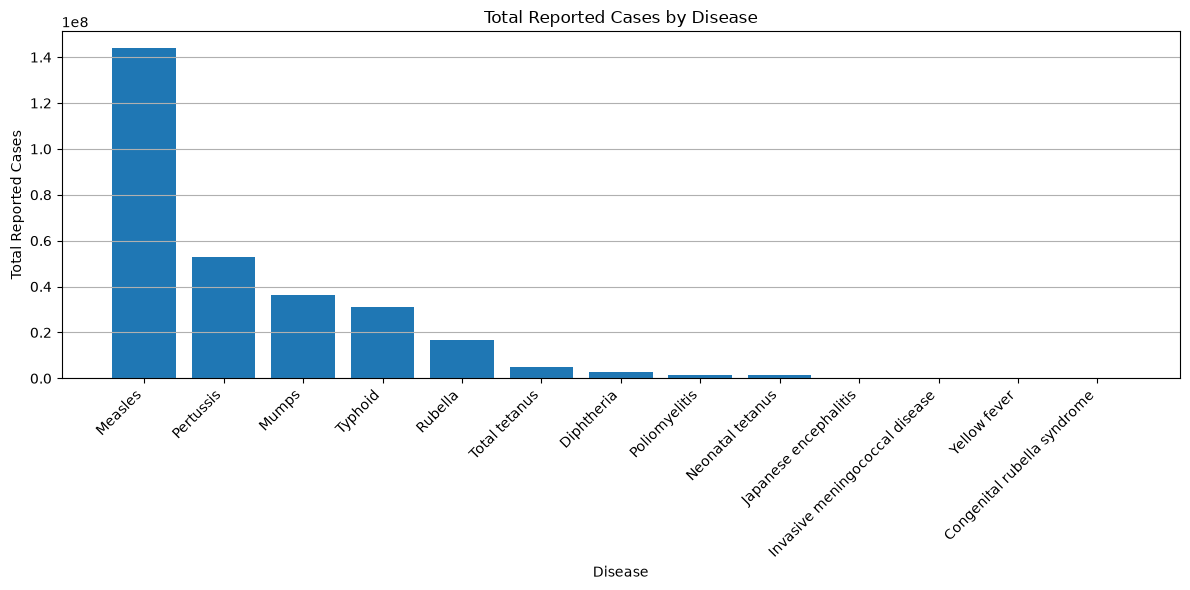

In [23]:
plt.figure(figsize=(12, 6))

plt.bar(
    reported_cases_by_disease["DISEASE_DESCRIPTION"],
    reported_cases_by_disease["CASES"]
)

plt.title("Total Reported Cases by Disease")
plt.xlabel("Disease")
plt.ylabel("Total Reported Cases")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [24]:
vaccine_introduction.head()
vaccine_introduction["INTRO"].describe()

count     138320
unique         9
top           No
freq       97695
Name: INTRO, dtype: object

In [25]:
vaccine_introduction_by_year = (
    vaccine_introduction
    .dropna(subset=["YEAR"])
    .groupby("YEAR", as_index=False)
    .size()
    .rename(columns={"size": "INTRODUCTIONS"})
)

vaccine_introduction_by_year.head(10)

,YEAR,INTRODUCTIONS
0,1940,164
1,1941,164
2,1942,164
3,1943,164
4,1944,164
5,1945,164
6,1946,164
7,1947,164
8,1948,164
9,1949,164


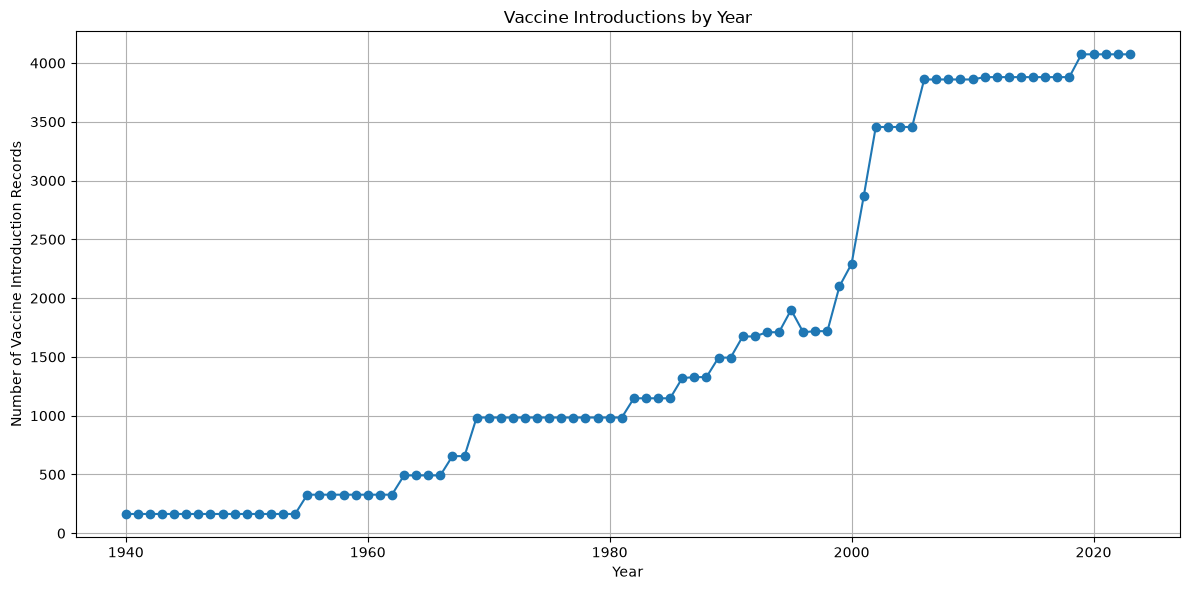

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    vaccine_introduction_by_year["YEAR"],
    vaccine_introduction_by_year["INTRODUCTIONS"],
    marker="o"
)

plt.title("Vaccine Introductions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Vaccine Introduction Records")
plt.grid(True)
plt.tight_layout()

plt.show()

In [27]:
vaccine_schedule.head()
vaccine_schedule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ISO_3_CODE             8052 non-null   object 
 1   COUNTRYNAME            8052 non-null   object 
 2   WHO_REGION             8052 non-null   object 
 3   YEAR                   8052 non-null   int64  
 4   VACCINECODE            8052 non-null   object 
 5   VACCINE_DESCRIPTION    8052 non-null   object 
 6   SCHEDULEROUNDS         8052 non-null   float64
 7   TARGETPOP              3795 non-null   object 
 8   TARGETPOP_DESCRIPTION  8052 non-null   object 
 9   GEOAREA                8022 non-null   object 
 10  AGEADMINISTERED        7007 non-null   object 
 11  SOURCECOMMENT          5139 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 755.0+ KB


In [28]:
vaccine_schedule_by_year = (
    vaccine_schedule
    .dropna(subset=["YEAR"])
    .groupby("YEAR", as_index=False)
    .size()
    .rename(columns={"size": "SCHEDULE_RECORDS"})
)

vaccine_schedule_by_year.head(10)

,YEAR,SCHEDULE_RECORDS
0,2019,90
1,2021,22
2,2022,67
3,2023,7873


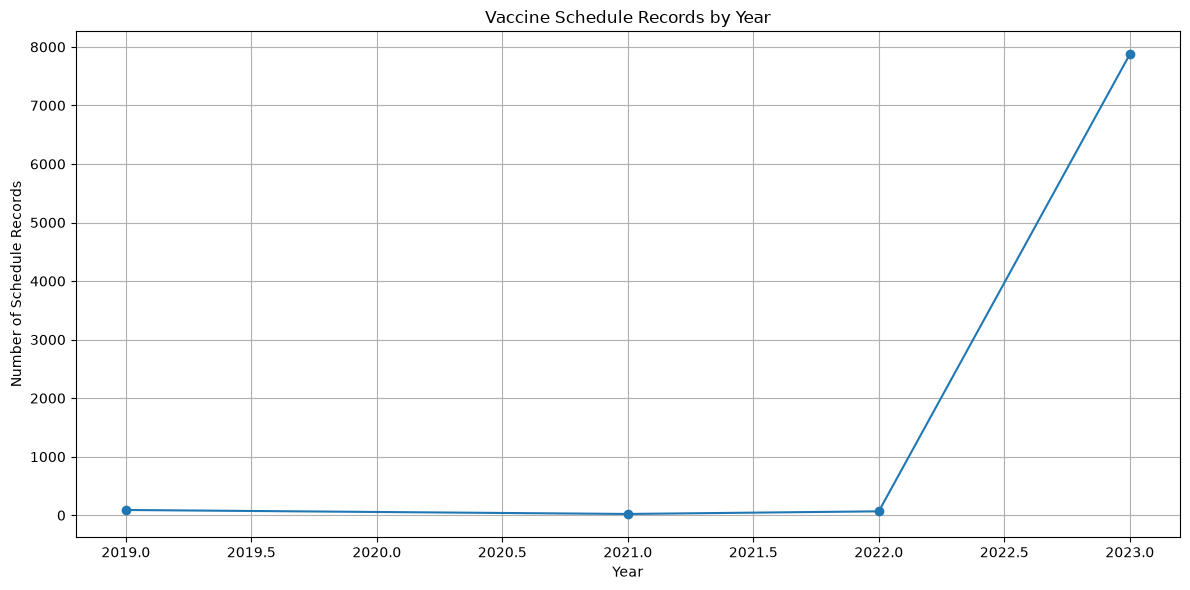

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    vaccine_schedule_by_year["YEAR"],
    vaccine_schedule_by_year["SCHEDULE_RECORDS"],
    marker="o"
)

plt.title("Vaccine Schedule Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Schedule Records")
plt.grid(True)
plt.tight_layout()

plt.show()

In [30]:
coverage_country_year = (
    coverage_eda
    .dropna(subset=["COVERAGE"])
    .groupby(["CODE", "YEAR"], as_index=False)["COVERAGE"]
    .mean()
)

reported_country_year = (
    reported_cases
    .dropna(subset=["CASES"])
    .groupby(["CODE", "YEAR"], as_index=False)["CASES"]
    .sum()
)

coverage_country_year.head()

,CODE,YEAR,COVERAGE
0,ABW,2017,96.320000
1,ABW,2018,91.200000
2,ABW,2019,91.750000
3,ABW,2021,88.349524
4,ABW,2022,88.750000


In [31]:
reported_country_year.head()

,CODE,YEAR,CASES
0,ABW,2017,2.0
1,ABW,2018,6.0
2,ABW,2019,2.0
3,ABW,2021,0.0
4,ABW,2022,4.0


In [32]:
coverage_cases = pd.merge(
    coverage_country_year,
    reported_country_year,
    on=["CODE", "YEAR"],
    how="inner"
)

coverage_cases.head()

,CODE,YEAR,COVERAGE,CASES
0,ABW,2017,96.320000,2.0
1,ABW,2018,91.200000,6.0
2,ABW,2019,91.750000,2.0
3,ABW,2021,88.349524,0.0
4,ABW,2022,88.750000,4.0


In [33]:
coverage_cases.shape

(8717, 4)

In [34]:
correlation = coverage_cases["COVERAGE"].corr(
    coverage_cases["CASES"]
)

print("Correlation between vaccination coverage and reported cases:", round(correlation, 3))

Correlation between vaccination coverage and reported cases: -0.203


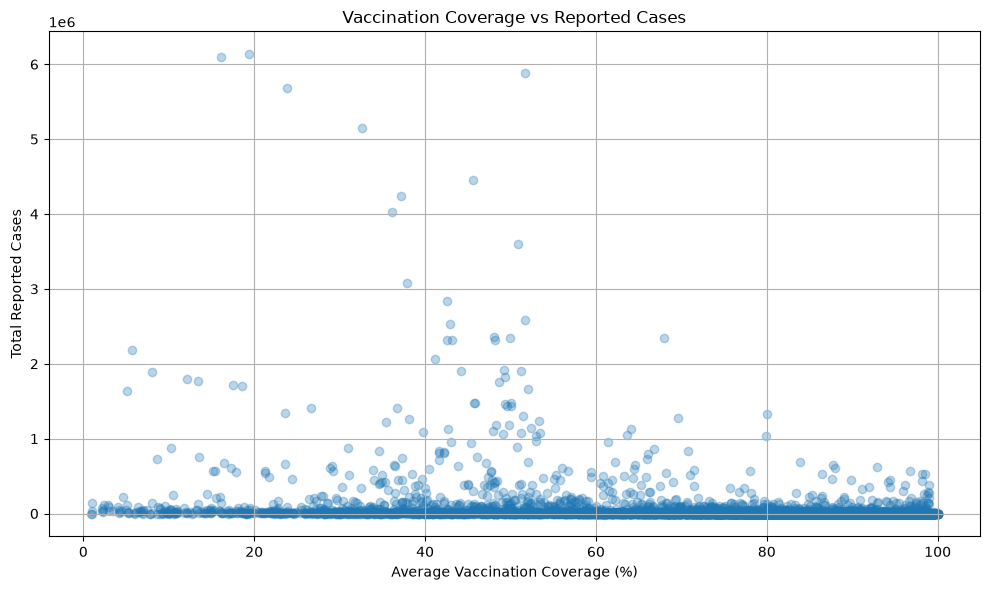

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    coverage_cases["COVERAGE"],
    coverage_cases["CASES"],
    alpha=0.3
)

plt.title("Vaccination Coverage vs Reported Cases")
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Total Reported Cases")
plt.grid(True)
plt.tight_layout()

plt.show()

In [36]:
incidence_country_year = (
    incidence
    .dropna(subset=["INCIDENCE_RATE"])
    .groupby(["CODE", "YEAR"], as_index=False)["INCIDENCE_RATE"]
    .mean()
)

incidence_country_year.head()

,CODE,YEAR,INCIDENCE_RATE
0,ABW,2017,2.375000
1,ABW,2018,5.127273
2,ABW,2019,1.860000
3,ABW,2021,0.000000
4,ABW,2022,3.100000


In [37]:
coverage_incidence = pd.merge(
    coverage_country_year,
    incidence_country_year,
    on=["CODE", "YEAR"],
    how="inner"
)

coverage_incidence.head()

,CODE,YEAR,COVERAGE,INCIDENCE_RATE
0,ABW,2017,96.320000,2.375000
1,ABW,2018,91.200000,5.127273
2,ABW,2019,91.750000,1.860000
3,ABW,2021,88.349524,0.000000
4,ABW,2022,88.750000,3.100000


In [38]:
correlation_incidence = coverage_incidence["COVERAGE"].corr(
    coverage_incidence["INCIDENCE_RATE"]
)

print(
    "Correlation between vaccination coverage and incidence rate:",
    round(correlation_incidence, 3)
)

Correlation between vaccination coverage and incidence rate: -0.197


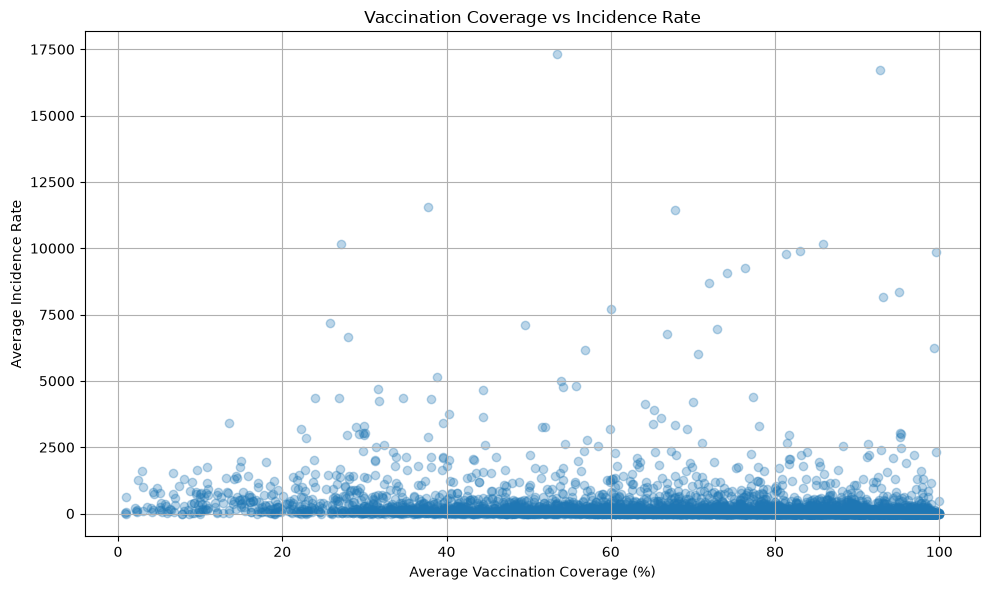

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(
    coverage_incidence["COVERAGE"],
    coverage_incidence["INCIDENCE_RATE"],
    alpha=0.3
)

plt.title("Vaccination Coverage vs Incidence Rate")
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Incidence Rate")
plt.grid(True)
plt.tight_layout()

plt.show()

In [40]:
coverage_region = (
    coverage_eda
    .dropna(subset=["COVERAGE"])
    .groupby(["GROUP"], as_index=False)["COVERAGE"]
    .mean()
    .sort_values("COVERAGE", ascending=False)
)

coverage_region["COVERAGE"] = coverage_region["COVERAGE"].round(2)

coverage_region

,GROUP,COVERAGE
0,COUNTRIES,79.77
1,DEVELOPMENT_STATUS,50.17
5,WB_LONG,48.62
7,WHO_REGIONS,48.37
4,UNICEF_REGIONS,46.89
6,WB_SHORT,46.81
3,GLOBAL,45.03
2,GAVI_PHASE5,44.00


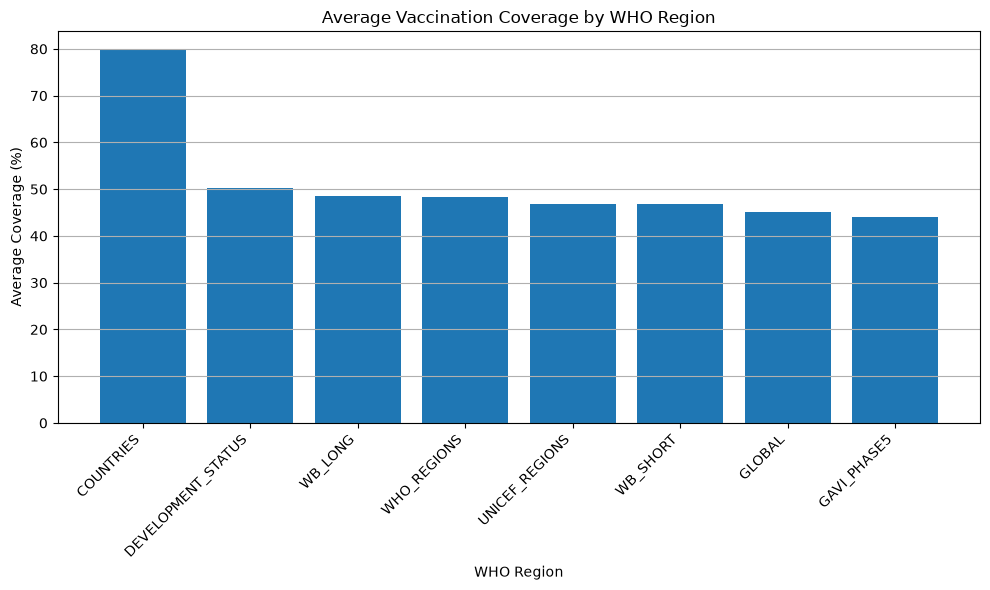

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(
    coverage_region["GROUP"],
    coverage_region["COVERAGE"]
)

plt.title("Average Vaccination Coverage by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [42]:
powerbi_coverage = (
    coverage_eda
    .groupby(
        ["CODE", "NAME", "YEAR"],
        as_index=False
    )["COVERAGE"]
    .mean()
)

powerbi_coverage["COVERAGE"] = (
    powerbi_coverage["COVERAGE"].round(2)
)

powerbi_coverage.head()

,CODE,NAME,YEAR,COVERAGE
0,ABW,Aruba,2017,96.32
1,ABW,Aruba,2018,91.20
2,ABW,Aruba,2019,91.75
3,ABW,Aruba,2021,88.35
4,ABW,Aruba,2022,88.75


In [43]:
powerbi_coverage.to_csv(
    "../data/cleaned/powerbi_coverage.csv",
    index=False
)

print("Saved:", len(powerbi_coverage), "rows")

Saved: 9947 rows


In [44]:
powerbi_reported_cases = (
    reported_cases
    .dropna(subset=["CASES"])
    .groupby(
        ["CODE", "NAME", "YEAR"],
        as_index=False
    )["CASES"]
    .sum()
)

powerbi_reported_cases["CASES"] = (
    powerbi_reported_cases["CASES"].round(0)
)

powerbi_reported_cases.head()

,CODE,NAME,YEAR,CASES
0,ABW,Aruba,2017,2.0
1,ABW,Aruba,2018,6.0
2,ABW,Aruba,2019,2.0
3,ABW,Aruba,2021,0.0
4,ABW,Aruba,2022,4.0


In [45]:
powerbi_reported_cases.to_csv(
    "../data/cleaned/powerbi_reported_cases.csv",
    index=False
)

print("Saved:", len(powerbi_reported_cases), "rows")

Saved: 8922 rows


In [46]:
powerbi_incidence = (
    incidence
    .dropna(subset=["INCIDENCE_RATE"])
    .groupby(
        ["CODE", "NAME", "YEAR"],
        as_index=False
    )["INCIDENCE_RATE"]
    .mean()
)

powerbi_incidence["INCIDENCE_RATE"] = (
    powerbi_incidence["INCIDENCE_RATE"].round(2)
)

powerbi_incidence.head()

,CODE,NAME,YEAR,INCIDENCE_RATE
0,ABW,Aruba,2017,2.38
1,ABW,Aruba,2018,5.13
2,ABW,Aruba,2019,1.86
3,ABW,Aruba,2021,0.00
4,ABW,Aruba,2022,3.10


In [47]:
powerbi_incidence.to_csv(
    "../data/cleaned/powerbi_incidence.csv",
    index=False
)

print("Saved:", len(powerbi_incidence), "rows")

Saved: 8830 rows


In [48]:
powerbi_introductions = (
    vaccine_introduction
    .dropna(subset=["YEAR"])
    .groupby(
        ["ISO_3_CODE", "COUNTRYNAME", "YEAR"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "INTRODUCTIONS"})
)

powerbi_introductions.head()

,ISO_3_CODE,COUNTRYNAME,YEAR,INTRODUCTIONS
0,AFG,Afghanistan,1940,1
1,AFG,Afghanistan,1941,1
2,AFG,Afghanistan,1942,1
3,AFG,Afghanistan,1943,1
4,AFG,Afghanistan,1944,1


In [49]:
powerbi_introductions.to_csv(
    "../data/cleaned/powerbi_introductions.csv",
    index=False
)

print("Saved:", len(powerbi_introductions), "rows")

Saved: 14715 rows


In [50]:
powerbi_schedule = (
    vaccine_schedule
    .dropna(subset=["YEAR"])
    .groupby(
        ["ISO_3_CODE", "COUNTRYNAME", "YEAR"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "SCHEDULE_RECORDS"})
)

powerbi_schedule.head()

,ISO_3_CODE,COUNTRYNAME,YEAR,SCHEDULE_RECORDS
0,ABW,Aruba,2023,37
1,AFG,Afghanistan,2023,24
2,AGO,Angola,2023,27
3,AIA,Anguilla,2023,42
4,ALB,Albania,2023,30


In [51]:
powerbi_schedule.to_csv(
    "../data/cleaned/powerbi_schedule.csv",
    index=False
)

print("Saved:", len(powerbi_schedule), "rows")

Saved: 213 rows


In [52]:
import os

powerbi_files = [
    "powerbi_coverage.csv",
    "powerbi_reported_cases.csv",
    "powerbi_incidence.csv",
    "powerbi_introductions.csv",
    "powerbi_schedule.csv"
]

for file in powerbi_files:
    path = os.path.join("../data/cleaned", file)
    print(
        file,
        "->",
        "FOUND" if os.path.exists(path) else "MISSING"
    )

powerbi_coverage.csv -> FOUND
powerbi_reported_cases.csv -> FOUND
powerbi_incidence.csv -> FOUND
powerbi_introductions.csv -> FOUND
powerbi_schedule.csv -> FOUND
